In [1]:
import torch

In [2]:
model = torch.load("generative_model.pt")

In [3]:
model

Joint(
  (prior): FlowDistribution(
    (base_distribution): IndependentNormal(
      (trainable_distribution): IndependentTrainableDistributionAdapter(
        distribution_class=<class 'torch.distributions.normal.Normal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
                0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), scale=tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
                1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
                1., 1., 1., 1., 1., 1., 1., 1., 1.]), event_dims=1
      )
    )
    (transform): SequentialTransform(
      (transforms): ModuleList(
        (0): InverseTransform(
          (transform): Softplus()
        )
        (1): Affine()
        (2): Tanh()
        (3): Affine()
        (4): Tanh()
        (5): Affine()
      )
    )
  )
  (conditional): IndependentNormal(
    (

In [4]:
flow = model.prior

In [5]:
samples = flow.sample((1000,))

In [6]:
samples.shape

torch.Size([1000, 45])

TypeError: can't multiply sequence by non-int of type 'float'

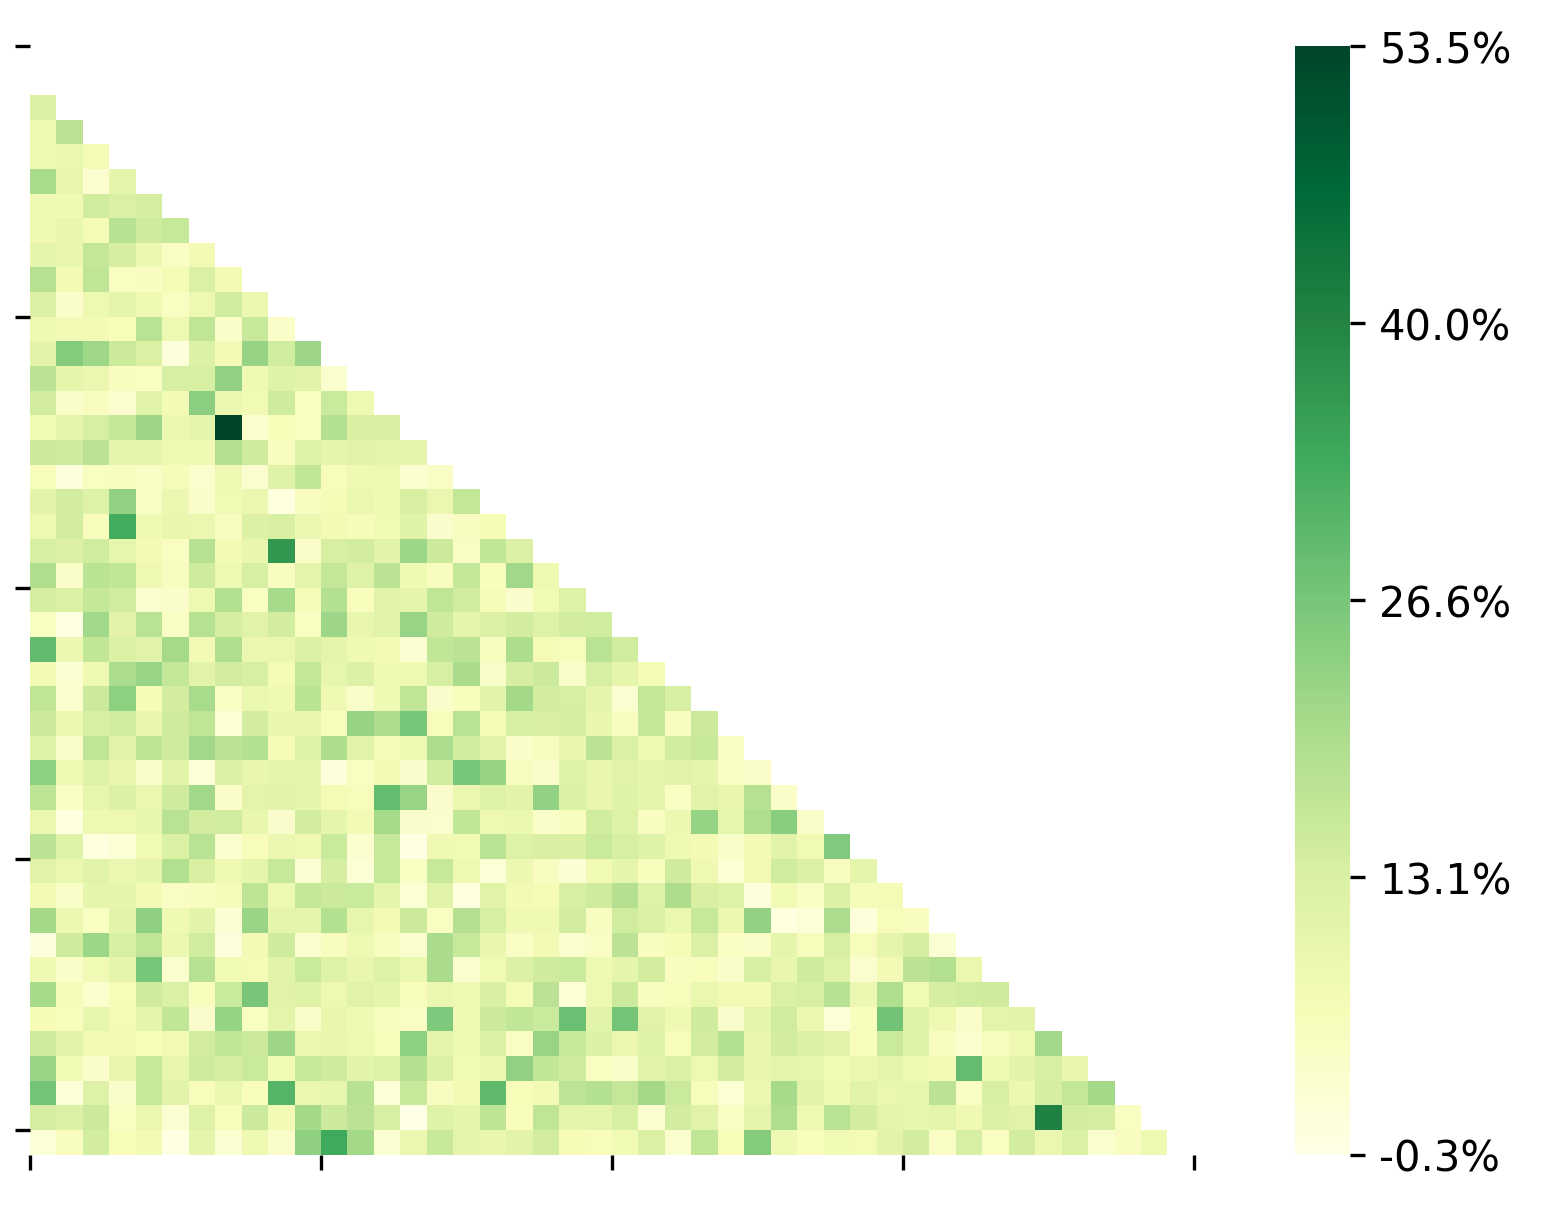

In [7]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
dpi=300,
fontsize=16,
linewidth=4,
tick_length=6,
tick_width=2,


xcorr = torch.corrcoef(samples.T).detach().cpu()
# consider only the lower triangle without the diagonal
mask = torch.triu(torch.ones_like(xcorr), diagonal=-1)
antimask = torch.tril(torch.ones_like(xcorr), diagonal=-1)
antimasked = antimask * xcorr
vmin = torch.min(antimasked).item()
vmax = torch.max(antimasked).item()
cbar_ticks = np.linspace(vmin, vmax, 5)
fig_xcorr, ax_xcorr = plt.subplots(dpi=300)
sns.heatmap(
    xcorr.numpy(),
    mask=mask.numpy(),
    cmap="YlGn",
    vmin=vmin,
    vmax=vmax,
    ax=ax_xcorr,
    cbar_kws={"ticks": cbar_ticks},
)

ax_xcorr.set_xticks(np.arange(0, 45, 11))
ax_xcorr.set_yticks(np.arange(0, 45, 11))

# xticklabels = ax_xcorr.set_xticklabels(
#     [f"${int(np.rad2deg(x))}^\\circ$" for x in model.x_phi[::11]]
# )
# yticklabels = ax_xcorr.set_yticklabels(
#     [f"${int(np.rad2deg(x))}^\\circ$" for x in model.x_phi[::11]]
# )

cbar = ax_xcorr.collections[0].colorbar
# here set the labelsize by 20
# cbar.ax.tick_params(labelsize=fontsize)
cbar.set_ticklabels([f"{x * 100:.1f}%" for x in cbar_ticks])
ax_xcorr.tick_params(
    axis="both",
    which="major",
    labelsize=fontsize,
    length=tick_length,
    width=tick_width,
)

ax_xcorr.set_ylabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
ax_xcorr.set_xlabel("Preferred orientation $\\psi^x$", fontsize=fontsize)
ax_xcorr.set_title("Pearson correlation of $x$ (prior)", fontsize=fontsize)



<Axes: ylabel='Probability'>

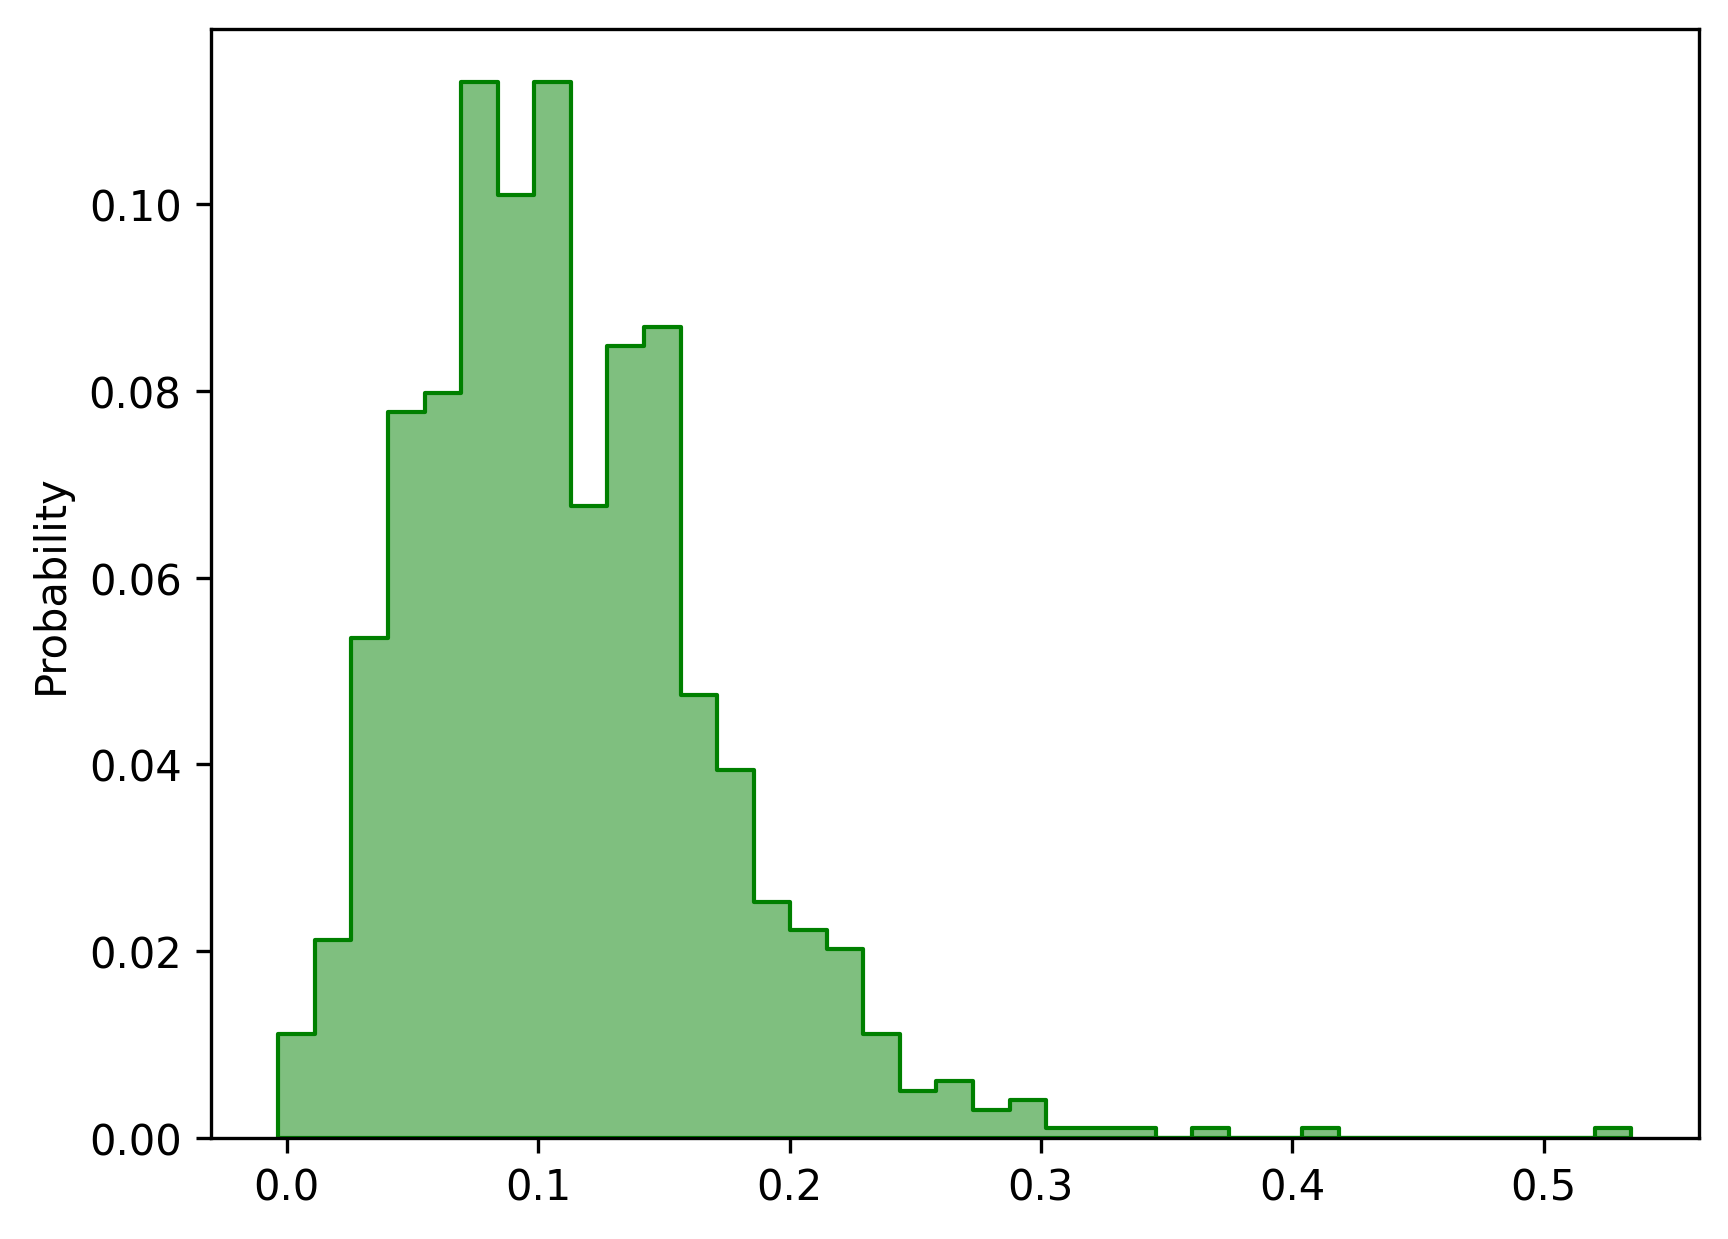

In [10]:
fig_xcorr_hist, ax_xcorr_hist = plt.subplots(dpi=300)

sns.histplot(
    torch.masked_select(xcorr, antimask.bool()),
    ax=ax_xcorr_hist,
    stat="probability",
    element="step",
    # kde=True,
    color="green",
    # label="No task",
    alpha=0.5,
    label="",
)
